In [3]:
import pandas as pd

In [4]:
ppmi_clean_counts_meta = pd.read_csv("/Volumes/Elements/counts/ppmi_clean_counts_meta.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/Elements/counts/ppmi_clean_counts_meta.csv'

In [5]:
ppmi_clean_counts_meta.head()

,Unnamed: 0,Patient,Gender,Visit,Diagnosis,ENSG00000223972.5,ENSG00000227232.5,ENSG00000278267.1,ENSG00000243485.5,ENSG00000284332.1,...,ENSG00000275757.1,ENSG00000278573.1,ENSG00000276017.1,ENSG00000278817.1,ENSG00000277196.4,ENSG00000278625.1,ENSG00000277374.1,Phase,IR,HudAlphaID
0,PPMI-Phase2-IR3.3174.V08.0000373111.5104-SL-0001,3174,Male,V08,PD,15,232,15,0,0,...,1,0,2,19,0,0,0,Phase2,IR3,5104-SL-0001
1,PPMI-Phase1-IR3.3201.BL.PP0016-0526.5104-SL-0002,3201,Female,BL,Control,2,199,10,0,0,...,0,0,0,3,0,0,0,Phase1,IR3,5104-SL-0002
2,PPMI-Phase1-IR3.3057.V06.0003125874.5104-SL-0003,3057,Female,V06,Control,0,148,2,1,0,...,2,0,1,15,3,0,0,Phase1,IR3,5104-SL-0003
3,PPMI-Phase2-IR3.4126.V04.0003179818.5104-SL-0004,4126,Male,V04,PD,6,216,16,0,0,...,0,0,1,2,2,0,0,Phase2,IR3,5104-SL-0004
4,PPMI-Phase1-IR3.4117.BL.0003164601.5104-SL-0005,4117,Female,BL,PD,0,95,3,0,0,...,0,0,0,12,1,0,0,Phase1,IR3,5104-SL-0005


In [6]:
ppmi_clean_counts_meta.index.values

array([   0,    1,    2, ..., 4753, 4754, 4755], shape=(4756,))

In [6]:
import anndata as ad


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.

In [7]:
ppmi_ad = ad.read_h5ad("/Users/kpax/Documents/aep/study/MSC/lab/PPMI_Project_133_RNASeq/ppmi_adata.h5ad")

In [9]:
ppmi_ad.obs.head()

,Sample,Diagnosis,Visit,Gender,Patient,Genetic_Group,Age_Group,Phase,IR,HudAlphaID
PPMI-Phase2-IR3.3174.V08.0000373111.5104-SL-0001,PPMI-Phase2-IR3.3174.V08.0000373111.5104-SL-0001,PD,V08,Male,3174,SRDC,50-70,Phase2,IR3,5104-SL-0001
PPMI-Phase1-IR3.3201.BL.PP0016-0526.5104-SL-0002,PPMI-Phase1-IR3.3201.BL.PP0016-0526.5104-SL-0002,Control,BL,Female,3201,None,50-70,Phase1,IR3,5104-SL-0002
PPMI-Phase1-IR3.3057.V06.0003125874.5104-SL-0003,PPMI-Phase1-IR3.3057.V06.0003125874.5104-SL-0003,Control,V06,Female,3057,None,50-70,Phase1,IR3,5104-SL-0003
PPMI-Phase2-IR3.4126.V04.0003179818.5104-SL-0004,PPMI-Phase2-IR3.4126.V04.0003179818.5104-SL-0004,PD,V04,Male,4126,SRDC,50-70,Phase2,IR3,5104-SL-0004
PPMI-Phase1-IR3.4117.BL.0003164601.5104-SL-0005,PPMI-Phase1-IR3.4117.BL.0003164601.5104-SL-0005,PD,BL,Female,4117,SRDC,50-70,Phase1,IR3,5104-SL-0005


In [13]:
ppmi_ad.obs[(ppmi_ad.obs['Diagnosis'].isin(['PD', 'Control'])) & (ppmi_ad.obs['Phase'].isin(['Phase1', 'Phase2']))]['Patient'].value_counts()

Patient
3854    5
3174    5
3201    5
3057    5
3804    5
       ..
3809    1
3290    1
3591    1
3330    1
3378    1
Name: count, Length: 618, dtype: int64

In [15]:
ppmi_ad.obs[ppmi_ad.obs["Patient"] == 3854]

,Sample,Diagnosis,Visit,Gender,Patient,Genetic_Group,Age_Group,Phase,IR,HudAlphaID
PPMI-Phase1-IR3.3854.BL.PP0021-3893.5104-SL-2554,PPMI-Phase1-IR3.3854.BL.PP0021-3893.5104-SL-2554,Control,BL,Male,3854,None,30-50,Phase1,IR3,5104-SL-2554
PPMI-Phase1-IR3.3854.V04.PP0014-4354.5104-SL-2555,PPMI-Phase1-IR3.3854.V04.PP0014-4354.5104-SL-2555,Control,V04,Male,3854,None,30-50,Phase1,IR3,5104-SL-2555
PPMI-Phase1-IR3.3854.V06.PP0028-4090.5104-SL-2556,PPMI-Phase1-IR3.3854.V06.PP0028-4090.5104-SL-2556,Control,V06,Male,3854,None,30-50,Phase1,IR3,5104-SL-2556
PPMI-Phase1-IR3.3854.V08.PP0042-0579.5104-SL-2557,PPMI-Phase1-IR3.3854.V08.PP0042-0579.5104-SL-2557,Control,V08,Male,3854,None,30-50,Phase1,IR3,5104-SL-2557
PPMI-Phase2-IR3.3854.V02.PP0007-9601.5104-SL-4512,PPMI-Phase2-IR3.3854.V02.PP0007-9601.5104-SL-4512,Control,V02,Male,3854,None,30-50,Phase2,IR3,5104-SL-4512


In [21]:
visit = "V02" # Specify the visit of interest
phase_counts = (
    ppmi_ad.obs[ppmi_ad.obs["Visit"] == visit]
    .groupby("Phase")["Sample"].count()
)
phase_pct = (phase_counts / phase_counts.sum()) * 100
print(phase_pct)

Phase
Phase1      0.0
Phase2    100.0
Name: Sample, dtype: float64


/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_16160/579491212.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Phase")["Sample"].count()


In [22]:
visits = ["BL", "V02", "V04", "V06", "V08"]
for visit in visits:
    print(f"Visit: {visit}")
    phase_counts = (
    ppmi_ad.obs[ppmi_ad.obs["Visit"] == visit]
        .groupby("Phase")["Sample"].count()
    )
    phase_pct = (phase_counts / phase_counts.sum()) * 100
    print(phase_pct)

Visit: BL
Phase
Phase1    45.03268
Phase2    54.96732
Name: Sample, dtype: float64
Visit: V02
Phase
Phase1      0.0
Phase2    100.0
Name: Sample, dtype: float64
Visit: V04
Phase
Phase1    43.871707
Phase2    56.128293
Name: Sample, dtype: float64
Visit: V06
Phase
Phase1    46.026097
Phase2    53.973903
Name: Sample, dtype: float64
Visit: V08
Phase
Phase1    69.797422
Phase2    30.202578
Name: Sample, dtype: float64


/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_16160/1224923128.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Phase")["Sample"].count()


/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_16160/1816029985.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Phase")["Sample"].count()


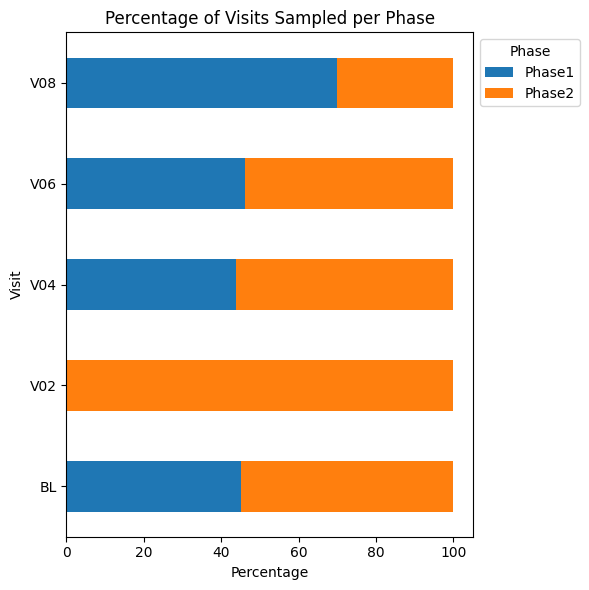

In [59]:
import matplotlib.pyplot as plt

visits = ["BL", "V02", "V04", "V06", "V08"]
phase_percentages = []

for visit in visits:
    phase_counts = (
        ppmi_ad.obs[ppmi_ad.obs["Visit"] == visit]
        .groupby("Phase")["Sample"].count()
    )
    phase_pct = (phase_counts / phase_counts.sum()) * 100
    phase_percentages.append(phase_pct)

# Convert data for plotting
phase_percentages_df = pd.DataFrame(phase_percentages, index=visits).fillna(0)

# Plot the barplot horizontally
phase_percentages_df.plot(kind="barh", stacked=True, figsize=(6, 6))
plt.title("Percentage of Visits Sampled per Phase")
plt.xlabel("Percentage")
plt.ylabel("Visit")
plt.legend(title="Phase", loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_39828/523634096.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Phase")["Sample"].count()


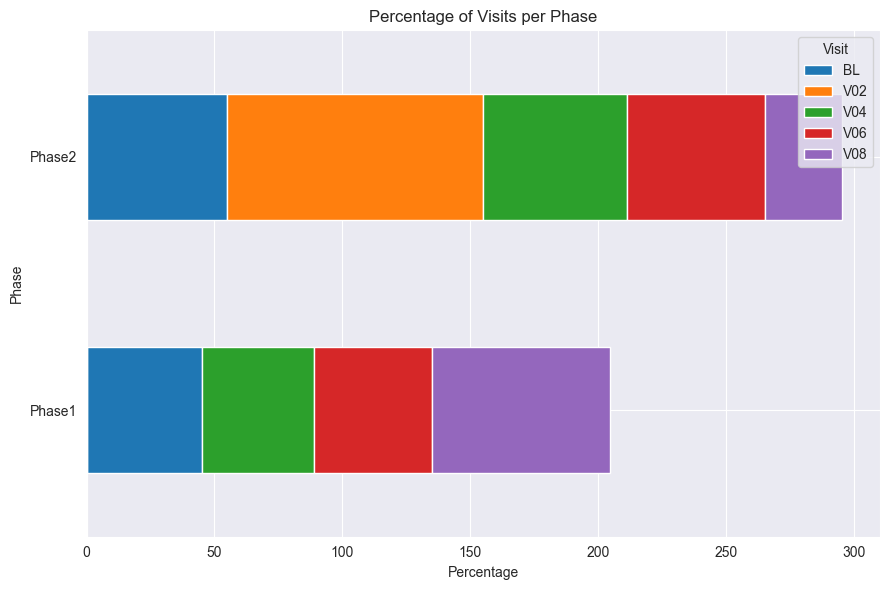

In [10]:
import matplotlib.pyplot as plt

# Data preparation
visits = ["BL", "V02", "V04", "V06", "V08"]
phase_percentages = []

# Collect percentage data for each phase and visit combination
for visit in visits:
    phase_counts = (
        ppmi_ad.obs[ppmi_ad.obs["Visit"] == visit]
        .groupby("Phase")["Sample"].count()
    )
    phase_pct = (phase_counts / phase_counts.sum()) * 100
    phase_percentages.append(phase_pct)

# Convert data for plotting
phase_percentages_df = pd.DataFrame(phase_percentages, index=visits).fillna(0)

# Transpose the DataFrame so visits are displayed as grouped categories
phase_percentages_df.T.plot(kind="barh", stacked=True, figsize=(9, 6))
plt.title("Percentage of Visits per Phase")
plt.xlabel("Percentage")
plt.ylabel("Phase")
plt.legend(title="Visit", loc="upper right")
plt.tight_layout()
plt.show()

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_39828/3661304779.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Phase")["Sample"].count()


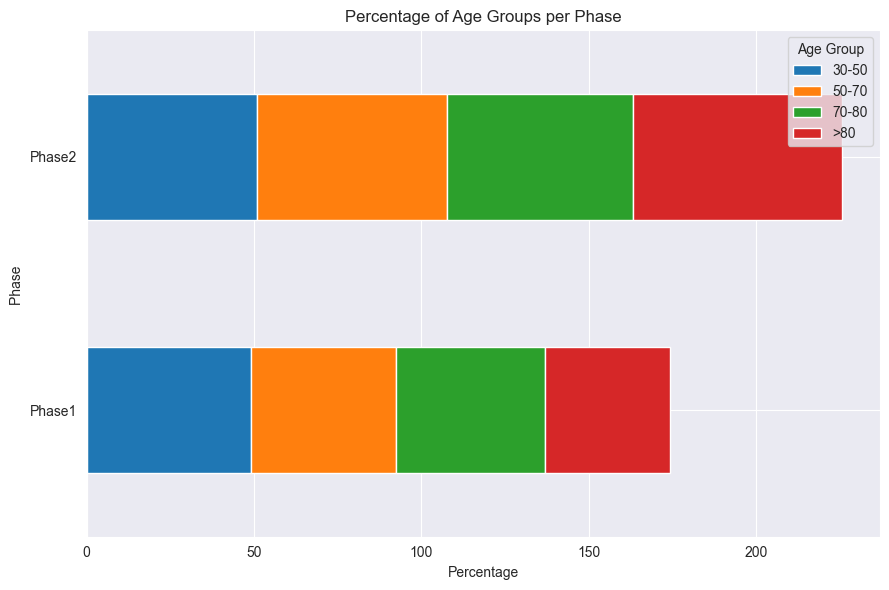

In [11]:
import matplotlib.pyplot as plt

# Data preparation
age_groups = ["30-50", "50-70", "70-80", ">80"]
gender = "Male"
phase_percentages = []

# Collect percentage data for each phase and visit combination
for age_group in age_groups:
    phase_counts = (
        ppmi_ad.obs[ppmi_ad.obs["Age_Group"] == age_group]
        .groupby("Phase")["Sample"].count()
    )
    phase_pct = (phase_counts / phase_counts.sum()) * 100
    phase_percentages.append(phase_pct)

# Convert data for plotting
phase_percentages_df = pd.DataFrame(phase_percentages, index=age_groups).fillna(0)

# Transpose the DataFrame so visits are displayed as grouped categories
phase_percentages_df.T.plot(kind="barh", stacked=True, figsize=(9, 6))
plt.title("Percentage of Age Groups per Phase")
plt.xlabel("Percentage")
plt.ylabel("Phase ")
plt.legend(title="Age Group", loc="upper right")
plt.tight_layout()
plt.show()